# SupplyLens: Supplier Delivery Risk and Operational Decision Intelligence

## 1. Executive summary

SupplyLens uses real public-health commodity shipment history to rank ASN/DN shipments by
the probability of arriving more than seven days after schedule. The recommended system is
a calibrated logistic-regression pipeline operated as an exact top-20% review queue. All
values below are loaded from executed, machine-readable project artifacts.

## 2. Business problem

Operations teams cannot investigate every shipment. The decision is which scheduled
shipments should receive scarce review attention before the actual delivery outcome is known.

## 3. Stakeholders

Supply-chain operations, procurement, supplier-management, transportation, inventory
planning, and data science teams are potential consumers. No organizational adoption is
claimed.

## 4. Decisions supported

The system supports risk-ranked review, supplier investigation, capacity planning, and
historical lead-time analysis. It does not automate supplier penalties, purchasing, routing,
or inventory decisions.

## 5. Success criteria

The primary criteria are precision-recall performance, lift and recall at fixed review
capacity, calibrated probability quality, temporal generalization, and a reproducible scoring
contract. Accuracy is not the primary metric for this imbalanced outcome.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
assert (ROOT / "pyproject.toml").exists(), "Run the notebook from the repository root."
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache" / "matplotlib"))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## 6. Data source

The selected source is the U.S. Agency for International Development Supply Chain Shipment
Pricing / SCMS Delivery History dataset. The retrieval script uses a commit-pinned public
mirror because the original catalog asset is no longer directly retrievable.

## 7. Data provenance

The raw file is checksum-verified and preserved unchanged. The accessible mirror does not
state an explicit redistribution license, so the raw CSV is downloaded locally and excluded
from version control. Full provenance and alternative-source review are in `docs/`.

In [2]:
# Execute the reproducible pipeline in dependency order. A pre-existing raw file is reused
# only after its pinned checksum is verified by the acquisition script.
commands = [
    [sys.executable, "scripts/download_data.py"],
    [sys.executable, "scripts/validate_data.py"],
    [sys.executable, "scripts/train.py"],
    [sys.executable, "scripts/build_reports.py"],
    [sys.executable, "scripts/build_readme.py"],
]
pipeline_log = []
for command in commands:
    completed = subprocess.run(command, cwd=ROOT, check=True, capture_output=True, text=True)
    pipeline_log.append({"command": " ".join(command[1:]), "status": "completed"})
pd.DataFrame(pipeline_log)

,command,status
0,scripts/download_data.py,completed
1,scripts/validate_data.py,completed
2,scripts/train.py,completed
3,scripts/build_reports.py,completed
4,scripts/build_readme.py,completed


## 8. Data dictionary

The field-level source-to-model mapping is maintained in `docs/DATA_DICTIONARY.md`.

In [3]:
quality = json.loads((ROOT / "reports/metrics/data_quality.json").read_text(encoding="utf-8"))
pd.DataFrame({
    "measure": ["source lines", "source columns", "modeled shipments", "severe delays", "severe-delay rate"],
    "value": [
        quality["raw"]["metrics"]["row_count"],
        quality["raw"]["metrics"]["column_count"],
        quality["processed"]["metrics"]["shipment_count"],
        quality["processed"]["metrics"]["severe_delay_count"],
        quality["processed"]["metrics"]["severe_delay_rate"],
    ],
})

,measure,value
0,source lines,"10,324.0000"
1,source columns,33.0000
2,modeled shipments,"7,030.0000"
3,severe delays,509.0000
4,severe-delay rate,0.0724


## 9. Data quality

Automated checks cover file checksum, schema and shape, identifiers, date parsing, numeric
ranges, duplicates, sequence anomalies, and expected categories. Retained warnings are shown
below rather than silently removed.

In [4]:
pd.DataFrame({'retained_warning': quality['raw']['warnings']})

,retained_warning
0,3 rows were recorded before the delivered date
1,4 rows arrived more than 365 days before their...


## 10. Target definition

The prediction unit is one ASN/DN shipment. A positive outcome is actual delivery strictly
more than seven calendar days after the latest scheduled-delivery date across its source
lines. The choice preserves operational relevance and sufficient positive volume; it was not
selected by model performance.

In [5]:
pd.read_csv(ROOT / 'reports/tables/target_threshold_prevalence.csv')

,delay_threshold_days,positive_shipments,prevalence
0,0,800,0.1138
1,3,657,0.0935
2,7,509,0.0724
3,14,326,0.0464


## 11. Leakage audit

Scoring occurs at scheduled-delivery commitment, used as the chronological proxy because the
source lacks the exact schedule-entry timestamp. Actual delivery, recorded date, computed
delay, outcomes, and target fields are explicitly blocklisted. Shifted historical target
features are implemented and tested but excluded from the production model because their
exact prediction-time availability cannot be guaranteed.

In [6]:
from supplylens.features import LEAKAGE_BLOCKLIST, MODEL_FEATURES, assert_no_leakage
assert_no_leakage(MODEL_FEATURES)
pd.DataFrame({"included_model_feature": MODEL_FEATURES})

,included_model_feature
0,country
1,managed_by
2,fulfill_via
3,vendor_inco_term
4,shipment_mode
5,product_group
6,sub_classification
7,supplier
8,molecule_test_type
9,brand


## 12. Exploratory analysis

The following executed figures answer target prevalence, drift, supplier, mode, missingness, and delay-distribution questions.

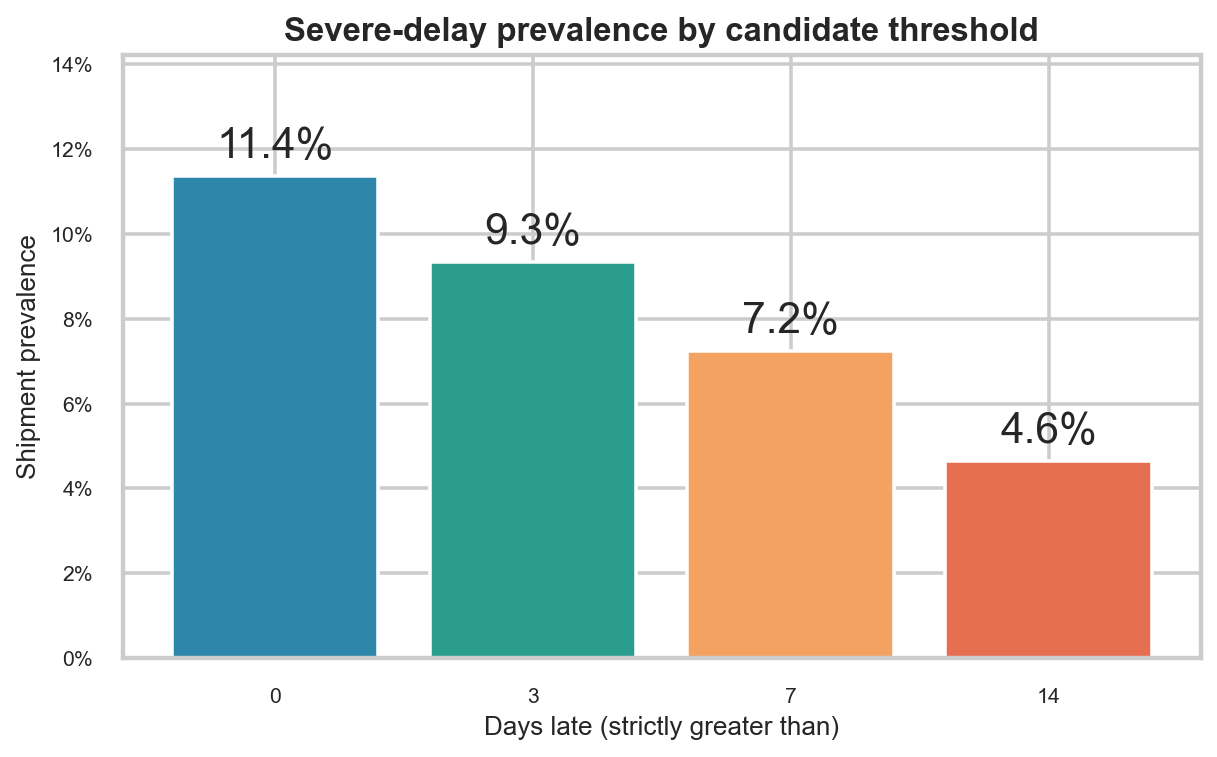

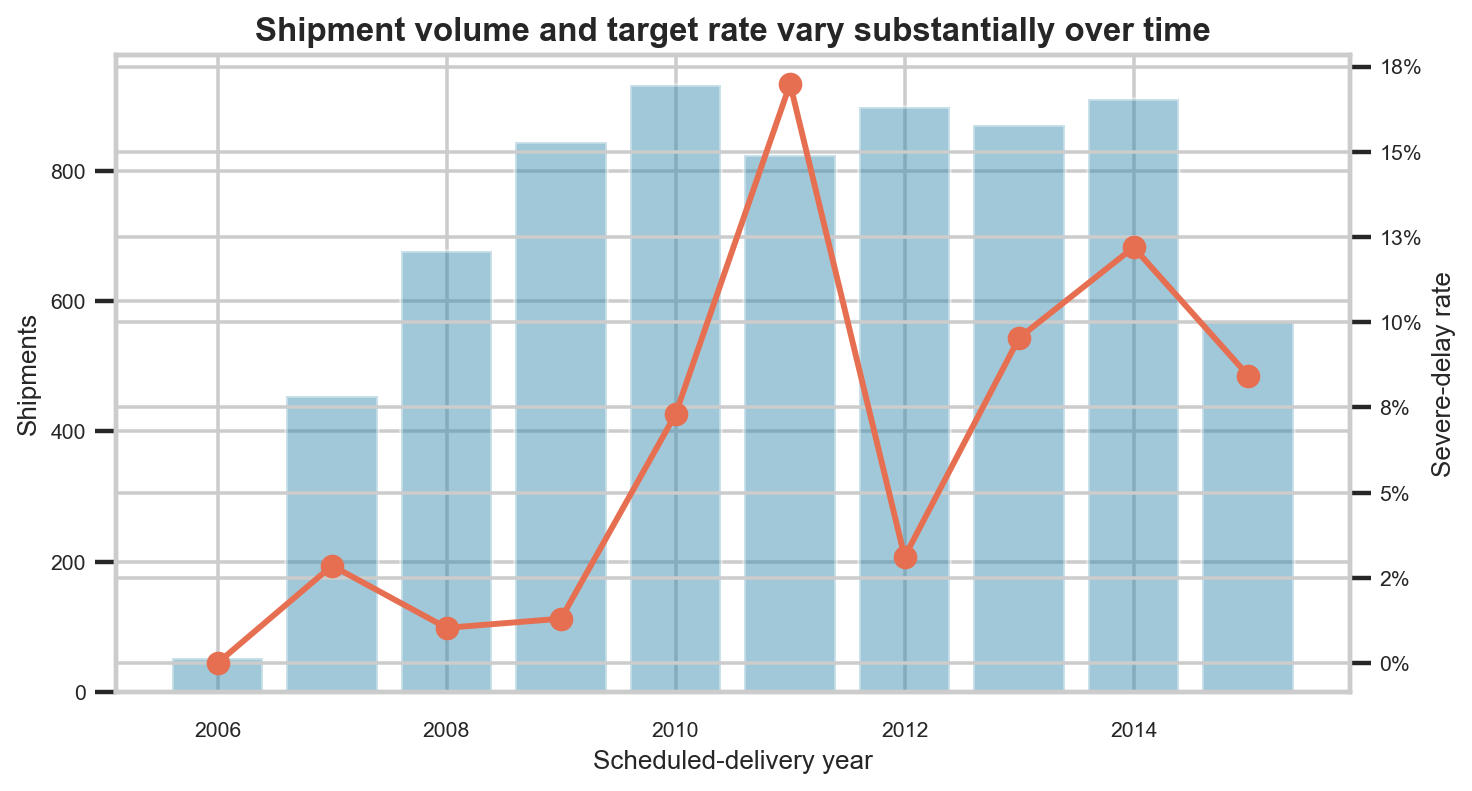

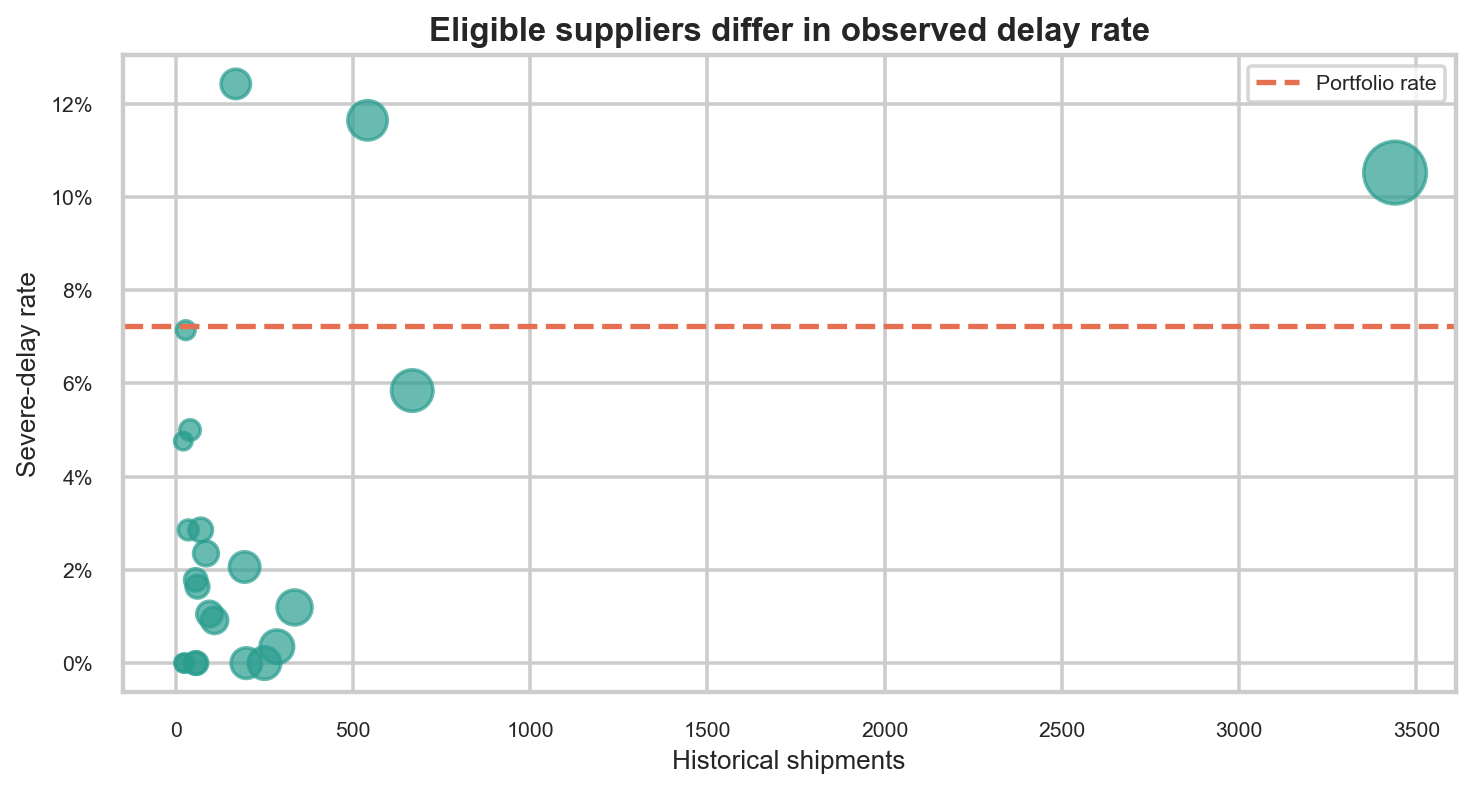

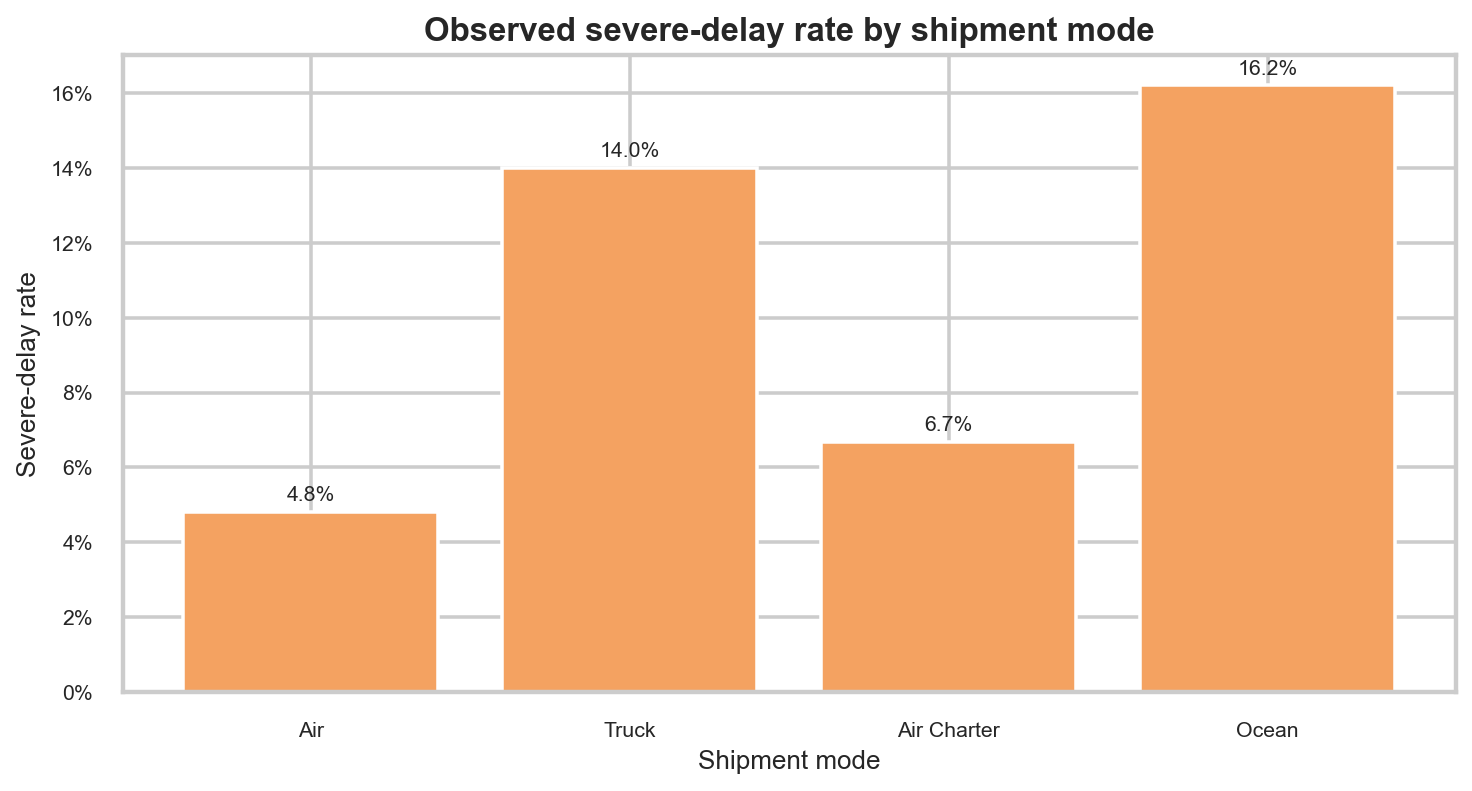

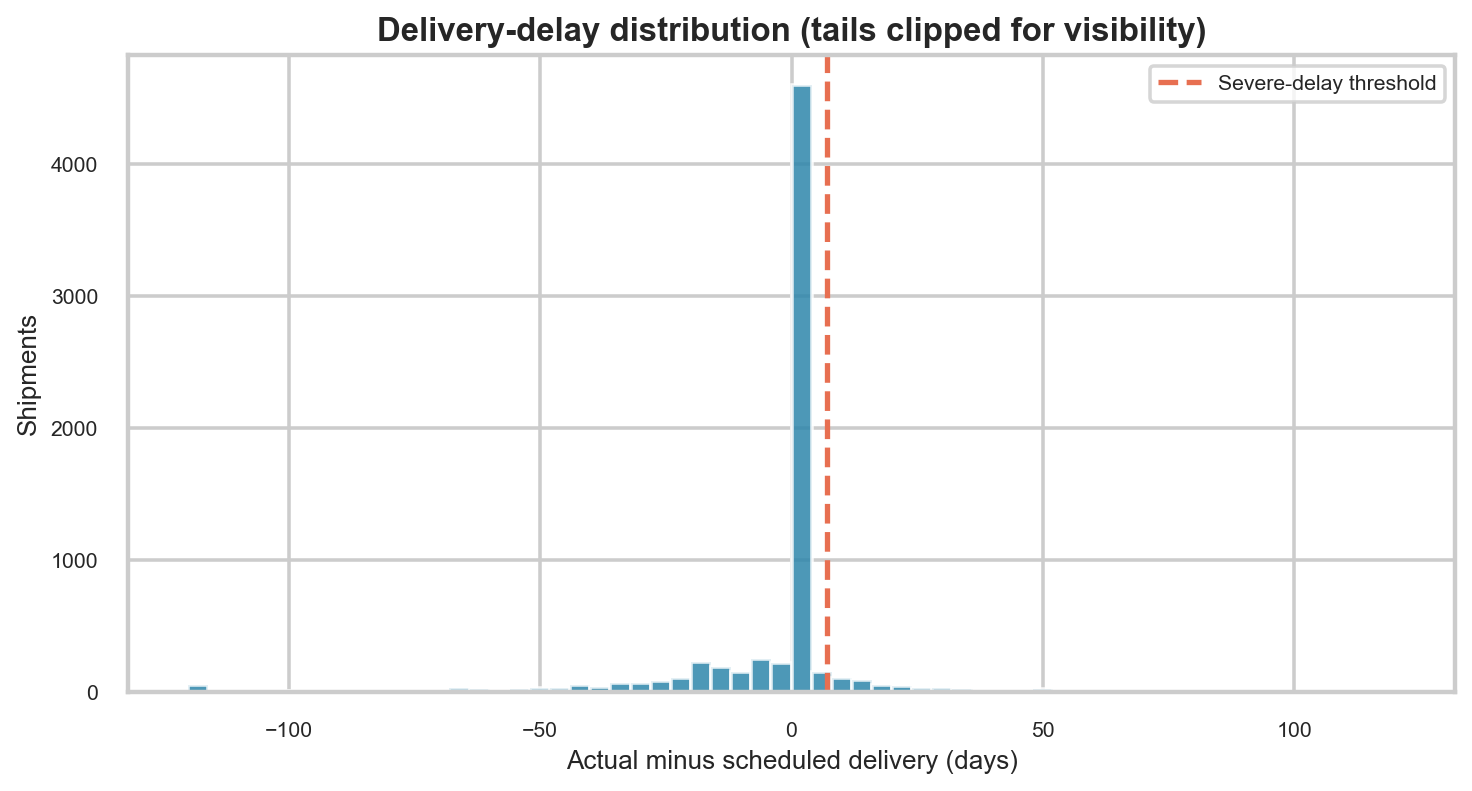

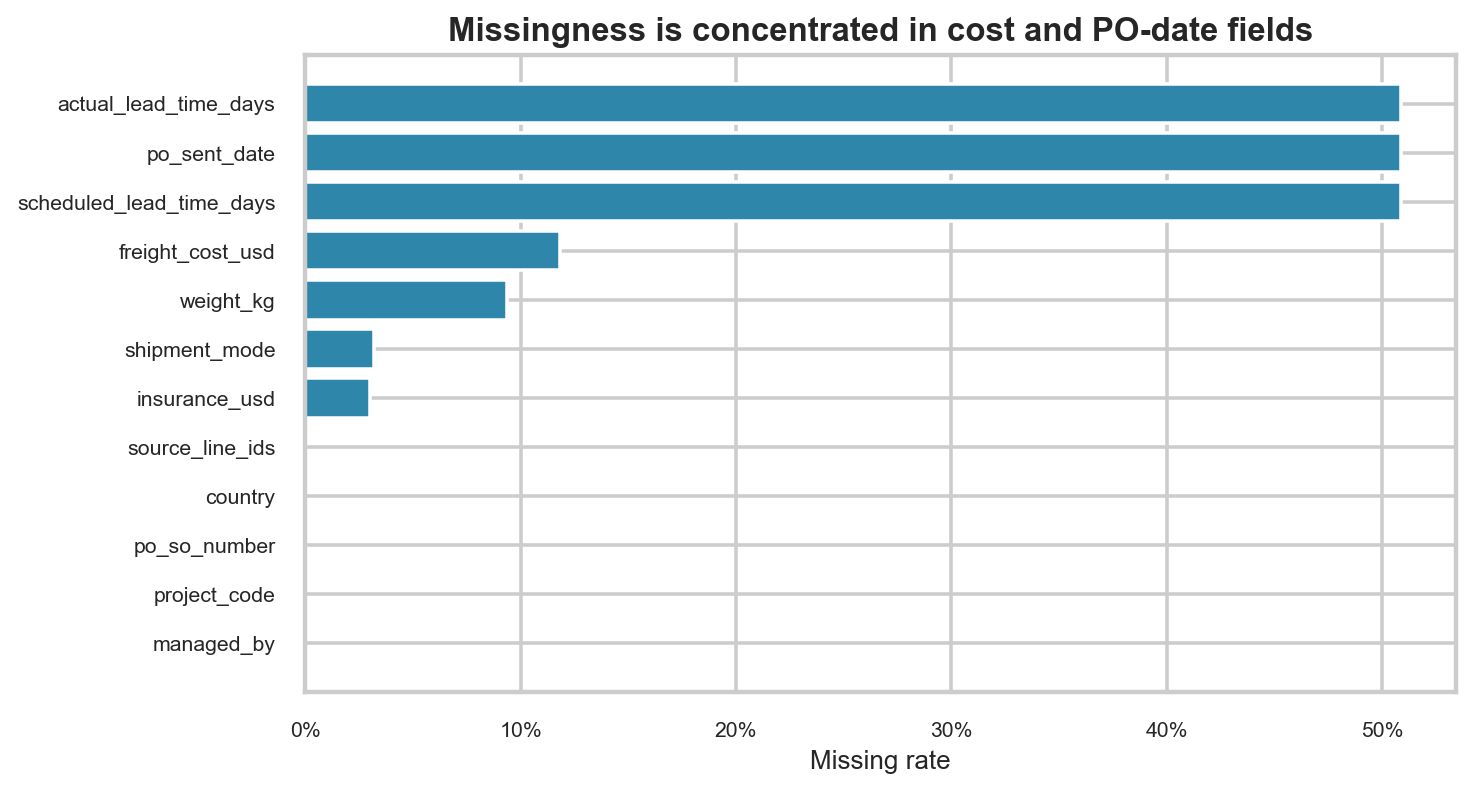

In [7]:
for name in ["target_prevalence.png", "volume_and_target_drift.png", "supplier_performance.png", "shipment_mode_performance.png", "delivery_delay_distribution.png", "missingness.png"]:
    display(Image(filename=str(ROOT / "reports/figures" / name), width=820))

## 13. Feature engineering

Reusable transformations create calendar indicators, log-scaled continuous measures,
missingness flags, and categorical encodings. Unique identifiers and all post-outcome fields
are excluded from predictive features.

## 14. Temporal split

Model selection uses a chronological training period and 2013 validation period. The
2014-2015 test period remains untouched until the complete model and calibration choice is
fixed.

In [8]:
metrics = json.loads((ROOT / "reports/metrics/final_metrics.json").read_text(encoding="utf-8"))
pd.DataFrame(metrics["splits"]).T

,rows,start,end,positive_shipments,prevalence
train,4681,2006-05-02,2012-12-31,267,0.0570
validation,870,2013-01-02,2013-12-31,83,0.0954
test,1479,2014-01-03,2015-12-31,159,0.1075


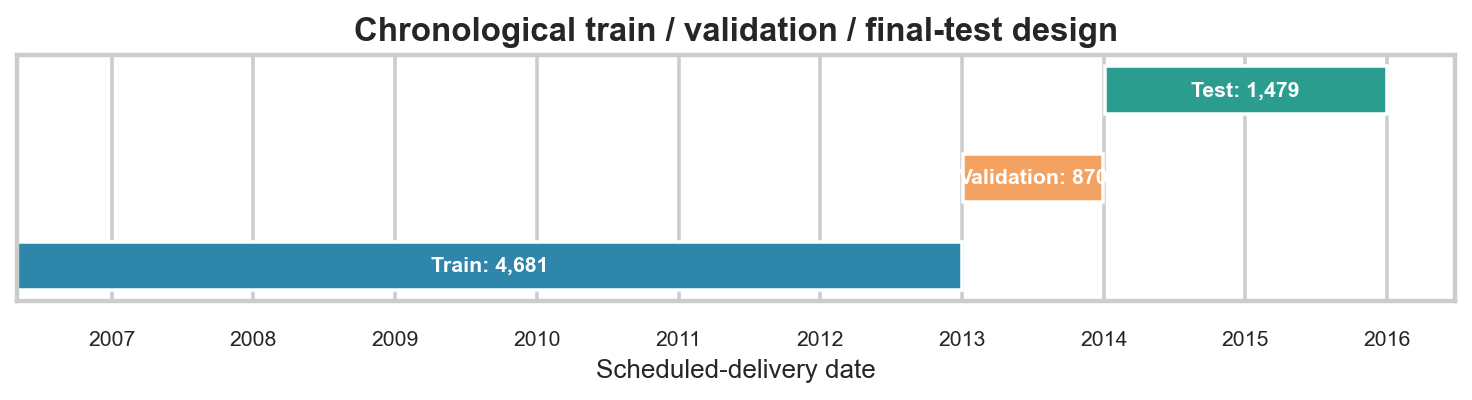

In [9]:
display(Image(filename=str(ROOT / 'reports/figures/temporal_split_timeline.png'), width=900))

## 15. Baselines

Validation compares the empirical-prevalence baseline, a smoothed prior-period supplier-rate
rule, and logistic regression. Continuous lead-time baselines include schedule, global,
supplier, and lane historical medians.

## 16. Advanced modeling

Histogram gradient boosting is the advanced classifier. Logistic regression remains the
selected model because gradient boosting did not clear the predeclared 0.01 validation
PR-AUC improvement margin.

In [10]:
pd.read_csv(ROOT / 'reports/tables/model_comparison.csv')

,model,roc_auc,pr_auc,brier_score,calibration_error
0,prevalence_baseline,0.5000,0.0954,0.0878,0.0384
1,supplier_rate_rule,0.6437,0.1380,0.0881,0.0616
2,logistic_regression,0.7461,0.1977,0.1615,0.2232
3,hist_gradient_boosting,0.7389,0.1870,0.1401,0.2161


## 17. Calibration

None, sigmoid, and isotonic calibration are compared only on validation labels. Isotonic calibration has the lowest validation Brier score and is retained.

In [11]:
pd.read_csv(ROOT / 'reports/tables/calibration_comparison.csv')

,method,brier_score,calibration_error,pr_auc
0,isotonic,0.0793,0.0000,0.2061
1,sigmoid,0.0815,0.0199,0.1977
2,none,0.1615,0.2232,0.1977


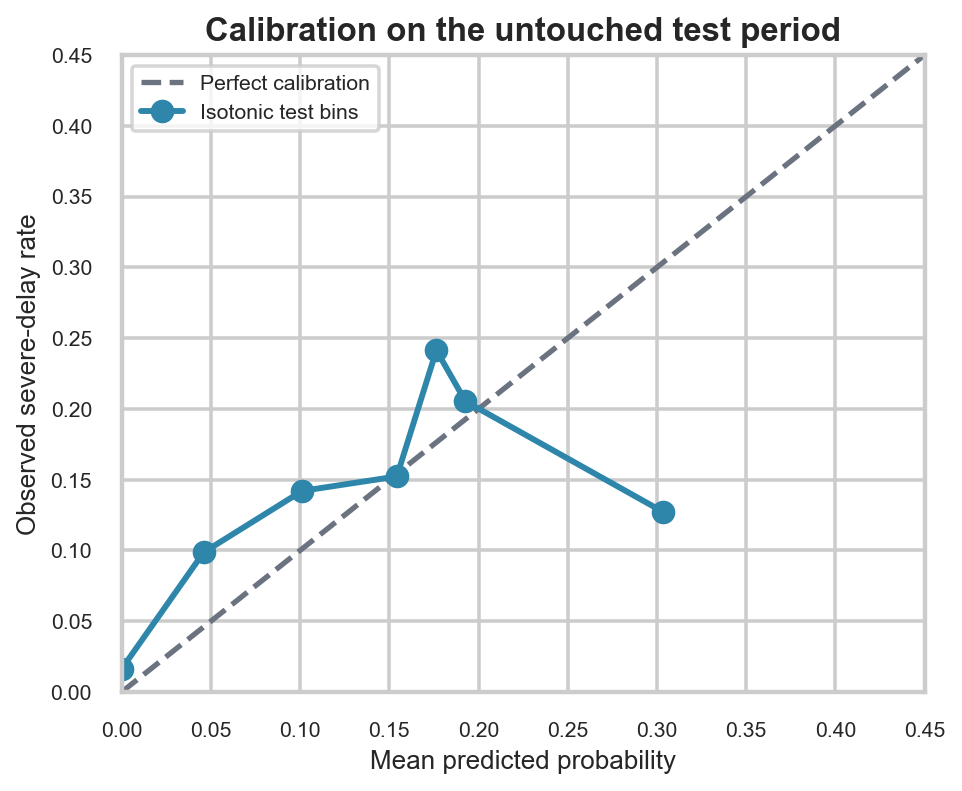

In [12]:
display(Image(filename=str(ROOT / 'reports/figures/calibration_plot.png'), width=850))

## 18. Threshold selection

The recommended policy ranks all shipments and reviews the exact highest-risk 20%. Capacity
policies of 5%, 10%, 20%, and 30% are evaluated. A separate cost-sensitive policy is labeled
as assumption-based because intervention economics are not observed in the source data.

In [13]:
pd.read_csv(ROOT / 'reports/tables/capacity_analysis_test.csv')

,capacity,shipments_reviewed,severe_delays_captured,precision,recall,lift,false_negatives,represented_shipment_value_usd
0,0.0500,74,7,0.0946,0.0440,0.8799,152,"41,791,456.4400"
1,0.1000,148,26,0.1757,0.1635,1.6341,133,"83,249,971.8100"
2,0.2000,296,56,0.1892,0.3522,1.7598,103,"190,060,667.0800"
3,0.3000,444,86,0.1937,0.5409,1.8017,73,"266,420,286.7700"


## 19. Final evaluation

The following final-period metrics were generated once for the selected calibrated system.

In [14]:
pd.DataFrame([metrics['test_metrics']]).T.rename(columns={0: 'value'})

,value
roc_auc,0.6963
pr_auc,0.1661
precision,0.1892
recall,0.3522
f1,0.2462
brier_score,0.0956
calibration_error,0.0360
threshold,0.1765
reviewed_count,296
tie_breaking,stable risk rank


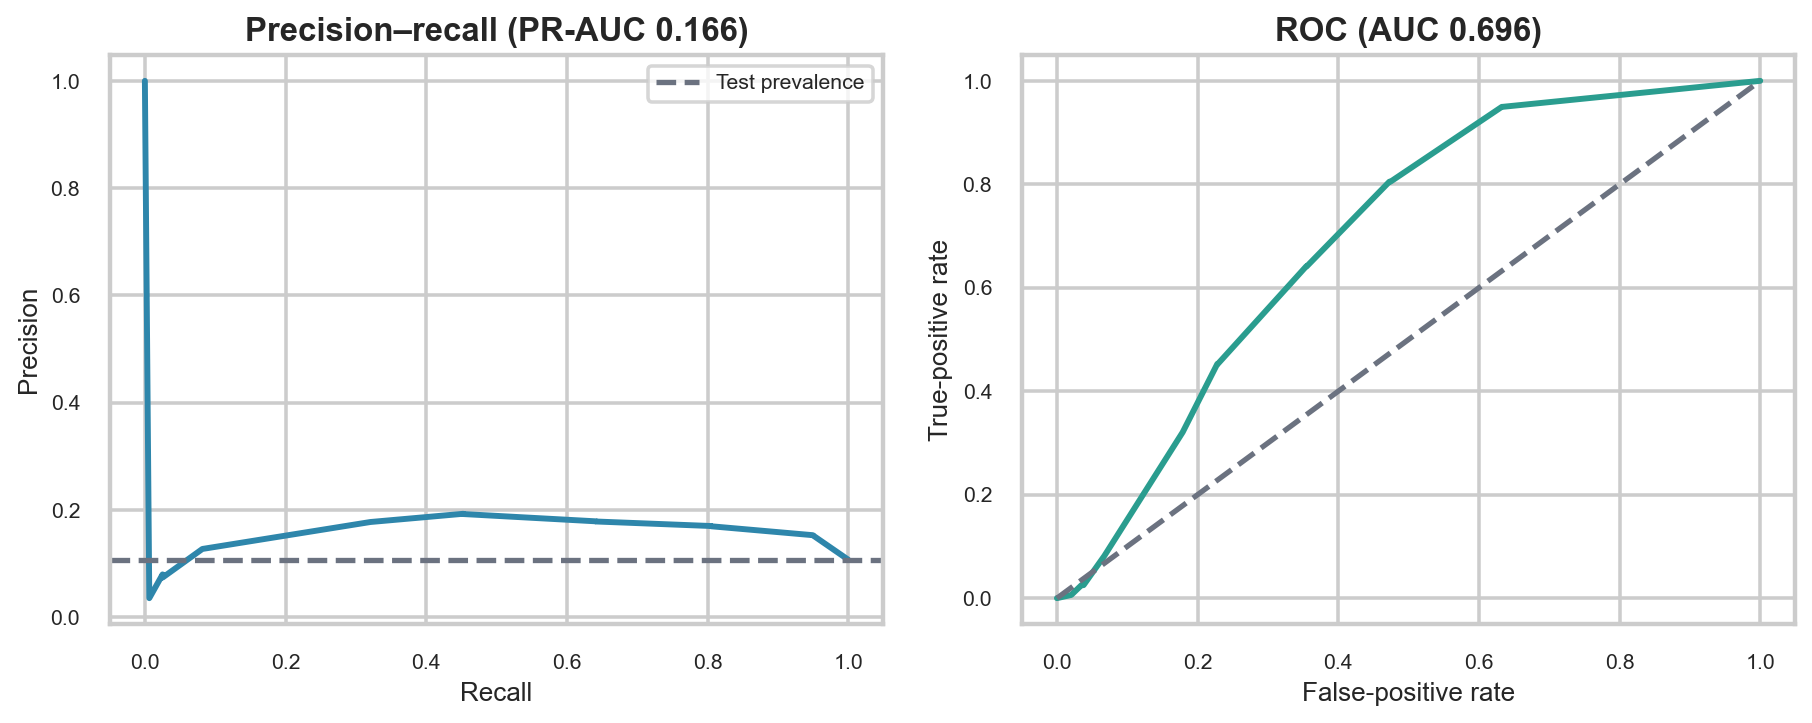

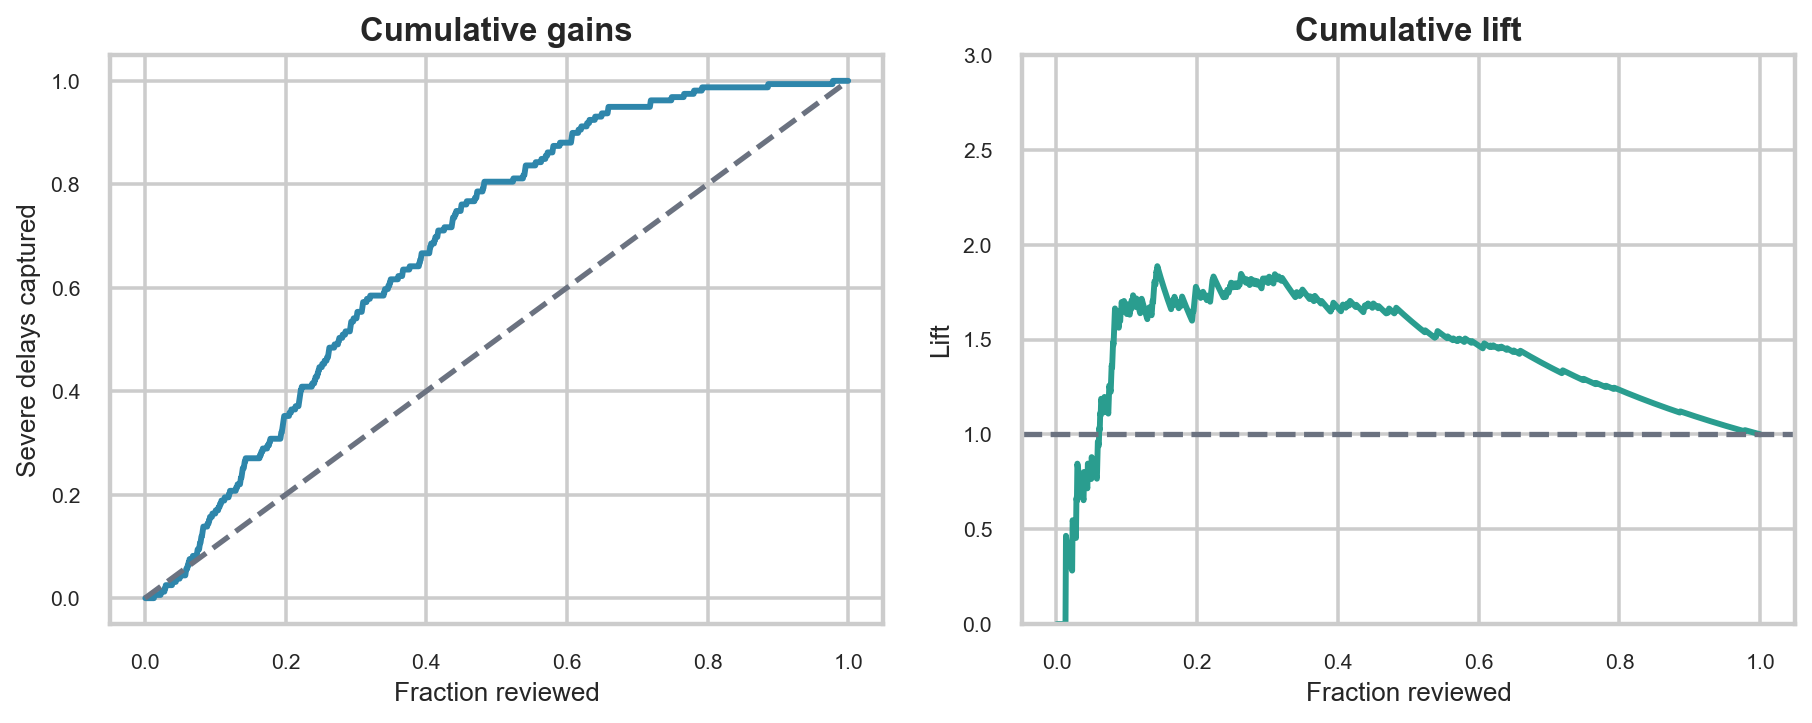

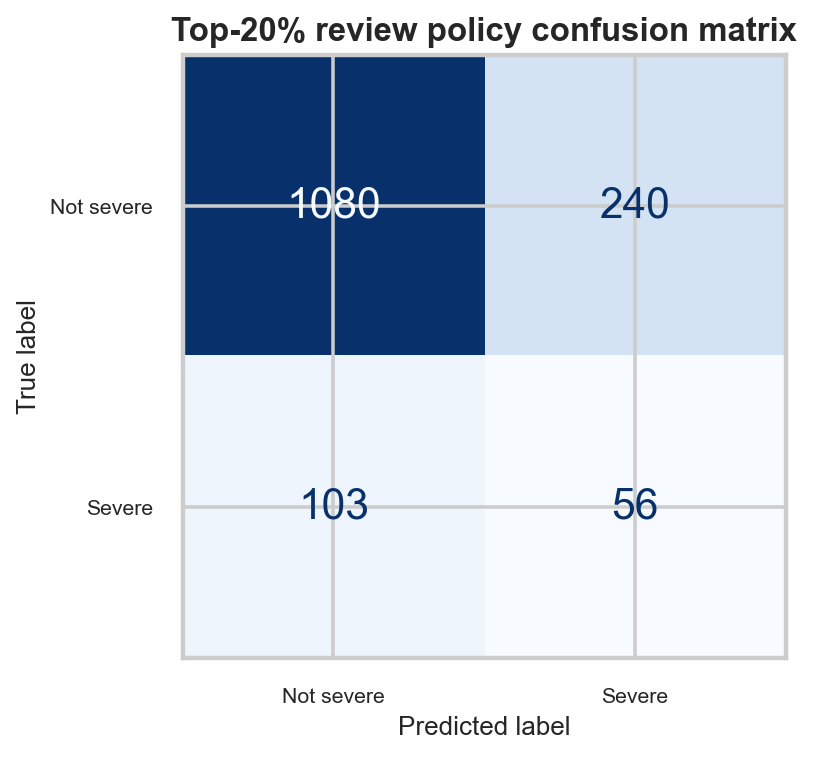

In [15]:
for name in ["pr_and_roc_curves.png", "gains_and_lift.png", "confusion_matrix.png"]:
    display(Image(filename=str(ROOT / "reports/figures" / name), width=850))

## 20. Explainability

Permutation importance summarizes global predictive associations. Queue-level local
contributors are based on controlled feature perturbations and use non-causal language.

In [16]:
pd.read_csv(ROOT / 'reports/tables/permutation_importance.csv').head(15)

,feature,importance_mean,importance_std
0,fulfill_via,0.0411,0.0028
1,log_insurance_usd,0.0196,0.0032
2,supplier,0.0191,0.0049
3,vendor_inco_term,0.0167,0.0029
4,shipment_mode,0.0130,0.0027
5,brand,0.0112,0.0022
6,freight_missing,0.0105,0.0018
7,log_freight_cost_usd,0.0102,0.0052
8,manufacturing_site,0.0074,0.0014
9,scheduled_month,0.0067,0.0021


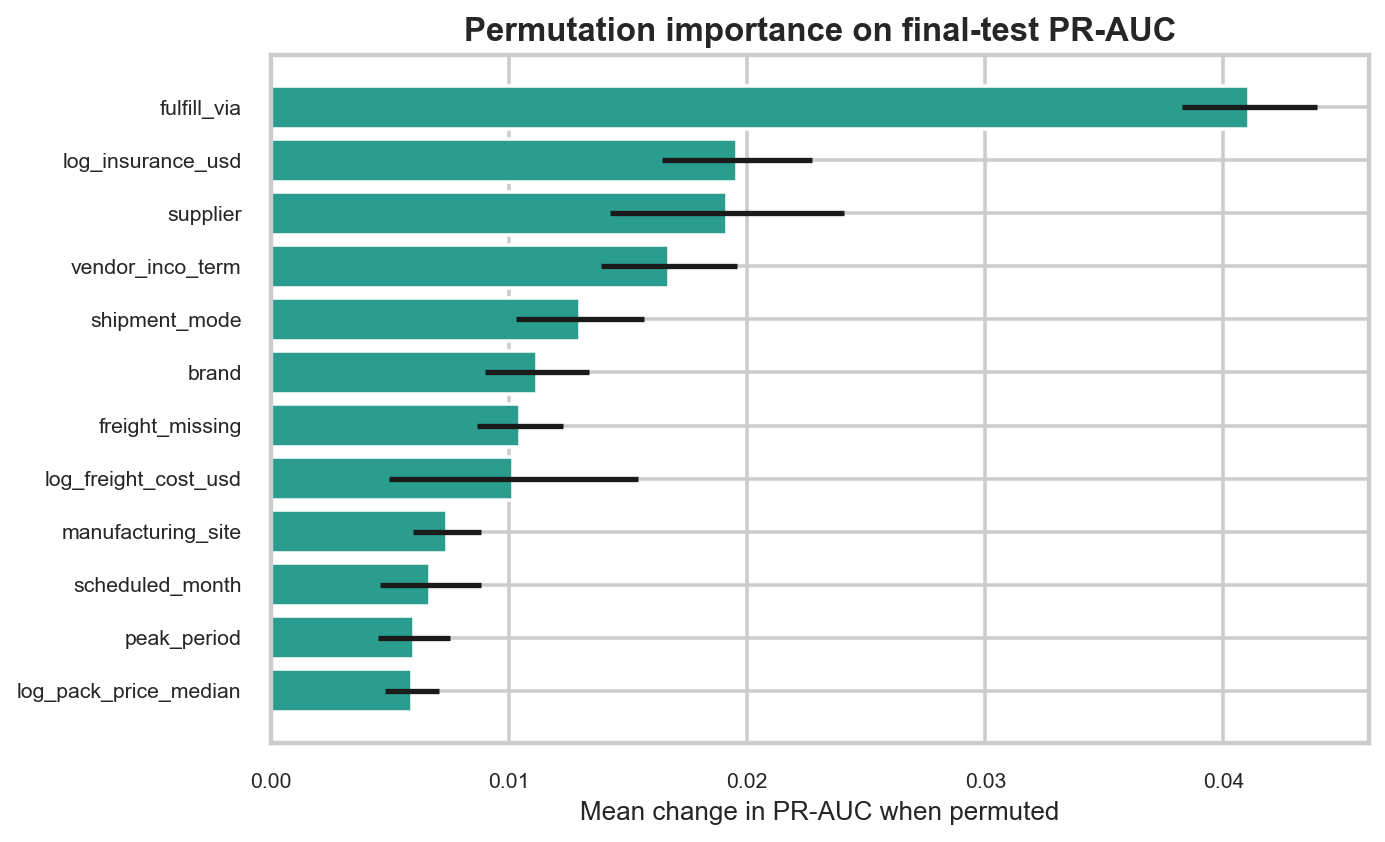

In [17]:
display(Image(filename=str(ROOT / 'reports/figures/permutation_importance.png'), width=850))

## 21. Segment analysis

Segment metrics include sample size, prevalence, precision, recall, false-negative rate, Brier score, and a low-volume reliability flag.

In [18]:
pd.read_csv(ROOT / 'reports/tables/segment_performance.csv').head(20)

,segment_type,segment,sample_size,positive_rate,precision,recall,false_negative_rate,brier_score,reliable_volume
0,supplier,ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV),104,0.0000,0.0000,NaN,NaN,0.0040,True
1,supplier,"ABBVIE, SRL (FORMALLY ABBOTT LABORATORIES INTE...",1,0.0000,0.0000,NaN,NaN,0.0371,False
2,supplier,ACOUNS NIGERIA LTD,1,0.0000,NaN,NaN,NaN,0.0239,False
3,supplier,AMSTELFARMA B.V.,3,0.0000,NaN,NaN,NaN,0.0000,False
4,supplier,ASPEN PHARMACARE,2,0.0000,NaN,NaN,NaN,0.0000,False
5,supplier,Aurobindo Pharma Limited,96,0.0000,0.0000,NaN,NaN,0.0209,True
6,supplier,B&C GROUP S.A.,2,0.0000,NaN,NaN,NaN,0.0000,False
7,supplier,BIO-RAD LABORATORIES (FRANCE),6,0.0000,NaN,NaN,NaN,0.0004,False
8,supplier,"CHEMBIO DIAGNOSTIC SYSTEMS, INC.",24,0.0000,NaN,NaN,NaN,0.0009,True
9,supplier,CIPLA LIMITED,31,0.0000,0.0000,NaN,NaN,0.0136,True


## 22. Error analysis

Examples below are drawn from the final temporal test period and labeled by error type.

In [19]:
pd.read_csv(ROOT / 'reports/tables/error_examples.csv').head(12)

,shipment_id,supplier,country,shipment_mode,predicted_severe_delay_probability,delivery_delay_days,severe_delay,example_type
0,DN-3432,SCMS from RDC,Zambia,Truck,0.5000,0,0,highest_risk
1,ASN-30228,PHARMACY DIRECT,South Africa,Truck,0.5000,0,0,false_positive
2,ASN-25925,"SHANGHAI KEHUA BIOENGINEERING CO.,LTD. (KHB)",Rwanda,Air,0.0000,49,1,false_negative


## 23. Lead-time experiment

Learned P50 and P90 gradient-boosting models are compared with scheduled and prior-period
median baselines. The learned P50 model is not recommended because it underperforms the
scheduled lead-time baseline; this negative result is preserved.

In [20]:
pd.read_csv(ROOT / 'reports/tables/lead_time_model_comparison.csv')

,model,mae_days,median_absolute_error_days,p50_pinball_loss
0,scheduled_lead_time,0.6998,0.0000,0.3499
1,learned_p50,4.4360,1.0158,2.2180
2,supplier_historical_median,57.2856,40.0000,28.6428
3,overall_historical_median,62.2360,48.0000,31.1180
4,lane_historical_median,63.4673,44.7500,31.7336


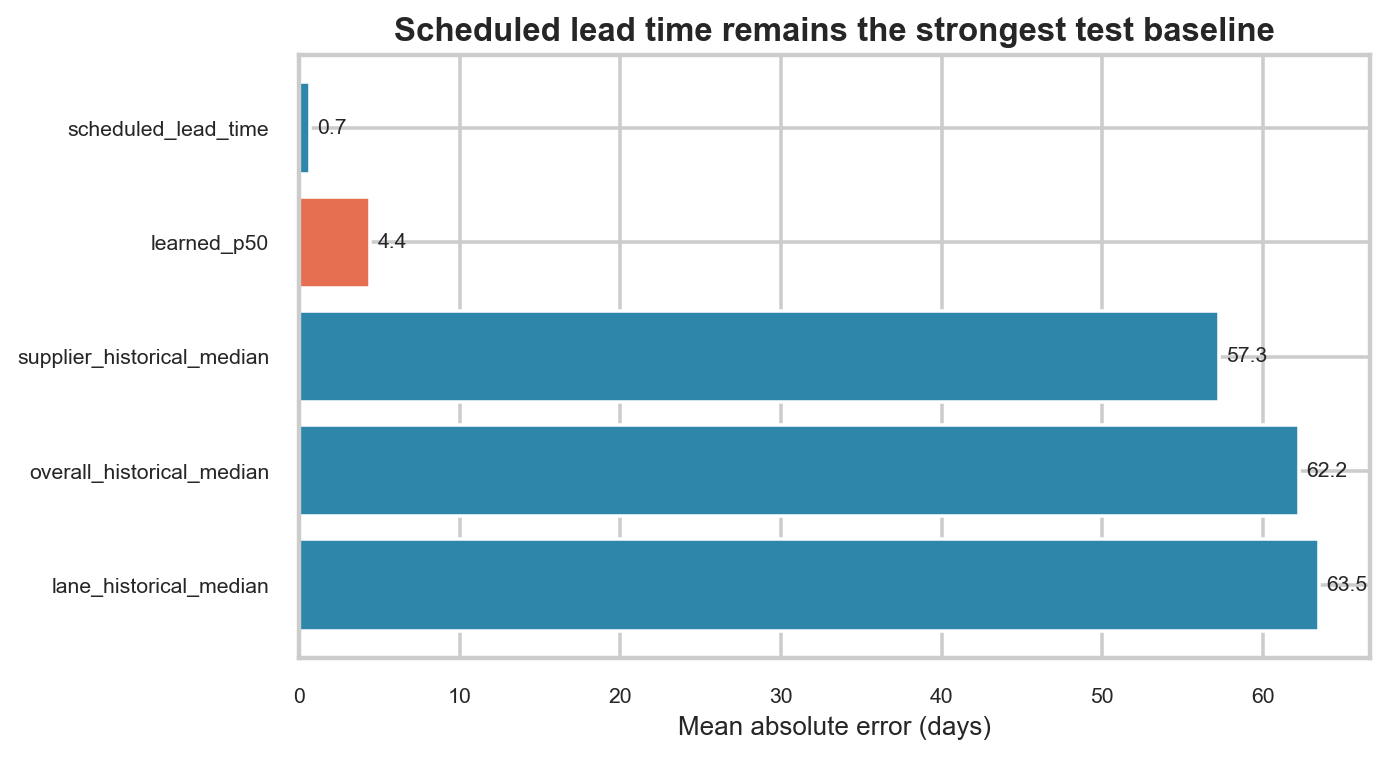

In [21]:
display(Image(filename=str(ROOT / 'reports/figures/lead_time_model_comparison.png'), width=850))

## 24. Shipment intervention queue

This final-period decision-support table is ranked by calibrated probability and carries the fixed capacity flag.

In [22]:
pd.read_csv(ROOT / 'reports/tables/shipment_intervention_queue.csv').head(10)

,shipment_id,supplier,product,country,shipment_mode,scheduled_delivery_date,predicted_severe_delay_probability,risk_rank,review_flag,total_value_usd,top_prediction_contributors
0,DN-3311,SCMS from RDC,"Nevirapine 10mg/ml, oral suspension w/syringe,...","Congo, DRC",Air,2014-01-21,0.5000,1,1,"12,361.0500",country (+0.250); managed_by (+0.000); fulfill...
1,DN-3432,SCMS from RDC,Efavirenz/Emtricitabine/Tenofovir Disoproxil F...,Zambia,Truck,2014-01-24,0.5000,2,1,"3,338,884.2000",molecule_test_type (+0.307); log_insurance_usd...
2,ASN-24548,PHARMACY DIRECT,Efavirenz/Emtricitabine/Tenofovir Disoproxil F...,South Africa,Truck,2014-02-05,0.5000,3,1,"206,791.0500",country (+0.275); molecule_test_type (+0.250);...
3,DN-3513,SCMS from RDC,"Abacavir/Lamivudine 60/30mg, tablets, 60 Tabs","Congo, DRC",Air,2014-03-26,0.5000,4,1,20.0000,log_total_quantity (+0.307); country (+0.250);...
4,DN-3590,SCMS from RDC,Efavirenz/Lamivudine/Tenofovir Disoproxil Fuma...,Ghana,Air,2014-04-07,0.5000,5,1,"343,838.3800",country (+0.324); log_freight_cost_usd (+0.259...
5,DN-3599,SCMS from RDC,"Tenofovir Disoproxil Fumarate 300mg, tablets, ...",Côte d'Ivoire,Truck,2014-04-30,0.5000,6,1,"773,280.0000",log_freight_cost_usd (+0.281); log_insurance_u...
6,DN-3612,SCMS from RDC,"Nevirapine 10mg/ml, oral suspension w/syringe,...",Mozambique,Truck,2014-05-23,0.5000,7,1,"48,732.0000",country (+0.250); shipment_mode (+0.250); sub_...
7,ASN-26372,Aurobindo Pharma Limited,"Efavirenz 50mg, capsule, 30 Caps",Ghana,Air,2014-06-12,0.5000,8,1,"23,091.1200",country (+0.324); sub_classification (+0.250);...
8,ASN-26373,Aurobindo Pharma Limited,"Lamivudine 10mg/ml, oral solution, Bottle, 240 ml",Ghana,Air,2014-06-12,0.5000,9,1,"8,647.2100",country (+0.324); sub_classification (+0.250);...
9,ASN-25862,CIPLA LIMITED,Efavirenz/Emtricitabine/Tenofovir Disoproxil F...,Ghana,Air,2014-06-17,0.5000,10,1,"284,053.8000",country (+0.250); managed_by (+0.000); fulfill...


## 25. Supplier scorecard

Supplier summaries require a minimum volume before performance priority is considered eligible.

In [23]:
pd.read_csv(ROOT / 'reports/tables/supplier_scorecard.csv').head(10)

,supplier,shipment_count,severe_delay_rate,average_delay_days,p90_delay_days,average_predicted_risk,high_risk_shipment_count,total_represented_shipment_value_usd,minimum_volume_eligible,performance_priority_score
0,PHARMACY DIRECT,58,0.0000,0.0000,0.0000,0.2339,32,"873,335.6600",True,0.9535
1,SCMS from RDC,620,0.2371,-10.3548,20.0000,0.1445,215,"341,276,125.3000",True,0.9294
2,"Orgenics, Ltd",141,0.0709,0.9220,5.0000,0.0928,16,"45,783,930.8500",True,0.4598
3,Aurobindo Pharma Limited,96,0.0000,0.0104,0.0000,0.1003,14,"7,115,766.3700",True,0.4587
4,S. BUYS WHOLESALER,29,0.0000,0.0000,0.0000,0.1247,10,"878,525.3600",True,0.4241
5,STRIDES ARCOLAB LIMITED,16,0.0000,0.8125,3.0000,0.0810,2,"2,489,781.7900",False,0.2295
6,CIPLA LIMITED,31,0.0000,0.0000,0.0000,0.0641,2,"2,621,323.4300",True,0.2222
7,ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV),104,0.0000,0.0000,0.0000,0.0338,3,"7,760,503.5900",True,0.1574
8,"ABBVIE, SRL (FORMALLY ABBOTT LABORATORIES INTE...",1,0.0000,0.0000,0.0000,0.1927,1,"148,250.8000",False,0.1335
9,"RAININ INSTRUMENT, LLC.",1,0.0000,0.0000,0.0000,0.1927,1,46.9000,False,0.1335


## 26. Replenishment indicators

These are historical planning scenarios based only on observed shipment quantity and lead-time variability; they are not inventory recommendations.

In [24]:
pd.read_csv(ROOT / 'reports/tables/replenishment_risk_indicators.csv').head(10)

,product_group,country,shipment_count,historical_shipped_quantity,quantity_variability,average_lead_time_days,p90_lead_time_days,lead_time_variability_days,severe_delay_rate,historical_safety_stock_scenario_units,risk_aware_replenishment_trigger
0,ARV,Benin,5,134245,"38,666.2455",46.0000,46.0000,NaN,0.4000,NaN,Elevated historical variability
1,ARV,Togo,3,13282,"3,629.7341",55.0000,55.0000,NaN,0.3333,NaN,Elevated historical variability
2,ARV,Burundi,35,173316,"10,904.5137",NaN,NaN,NaN,0.2571,NaN,Elevated historical variability
3,ARV,"Congo, DRC",84,468182,"13,495.8273",148.2917,195.7000,44.3136,0.2500,"14,036.5002",Elevated historical variability
4,ARV,South Sudan,24,170533,"11,869.9837",113.0000,127.2000,17.3494,0.1667,"3,199.0847",Elevated historical variability
5,ARV,Mozambique,326,18934670,"103,295.0111",149.9250,206.6000,51.1886,0.1656,"610,126.9232",Elevated historical variability
6,ARV,South Africa,581,22995781,"65,373.3654",130.3970,264.0000,98.1616,0.1532,"1,026,111.7331",Elevated historical variability
7,HRDT,Nigeria,205,1007557,"5,095.3461",90.3478,133.0000,40.5494,0.1317,"28,895.9689",Watch historical variability
8,ARV,Guatemala,8,55467,"13,052.9570",167.6667,356.0000,168.2649,0.1250,"3,240.4631",Watch historical variability
9,ARV,Ghana,45,1296566,"30,501.9954",119.0312,171.0000,51.7273,0.1111,"41,998.1358",Watch historical variability


## 27. Causal-readiness analysis

The observational fulfillment-path comparison has weak overlap and residual imbalance. The
project therefore reports diagnostics and associations, not a causal effect, and recommends
a randomized or credible quasi-experimental design with additional decision context.

In [25]:
causal = json.loads((ROOT / "reports/metrics/causal_readiness.json").read_text(encoding="utf-8"))
pd.json_normalize(causal).T

,0
treatment,Fulfill Via equals From RDC
outcome,Severe delay greater than 7 days
propensity_auc,0.9416
below_0_05_or_above_0_95_fraction,0.4084
maximum_absolute_smd_before,0.9654
maximum_absolute_smd_after_weighting,0.4618
trimming_sensitivity,"[{'trim_bound': 0.01, 'retained_rows': 5337, '..."
identification_conclusion,No causal effect is reported. Fulfillment assi...


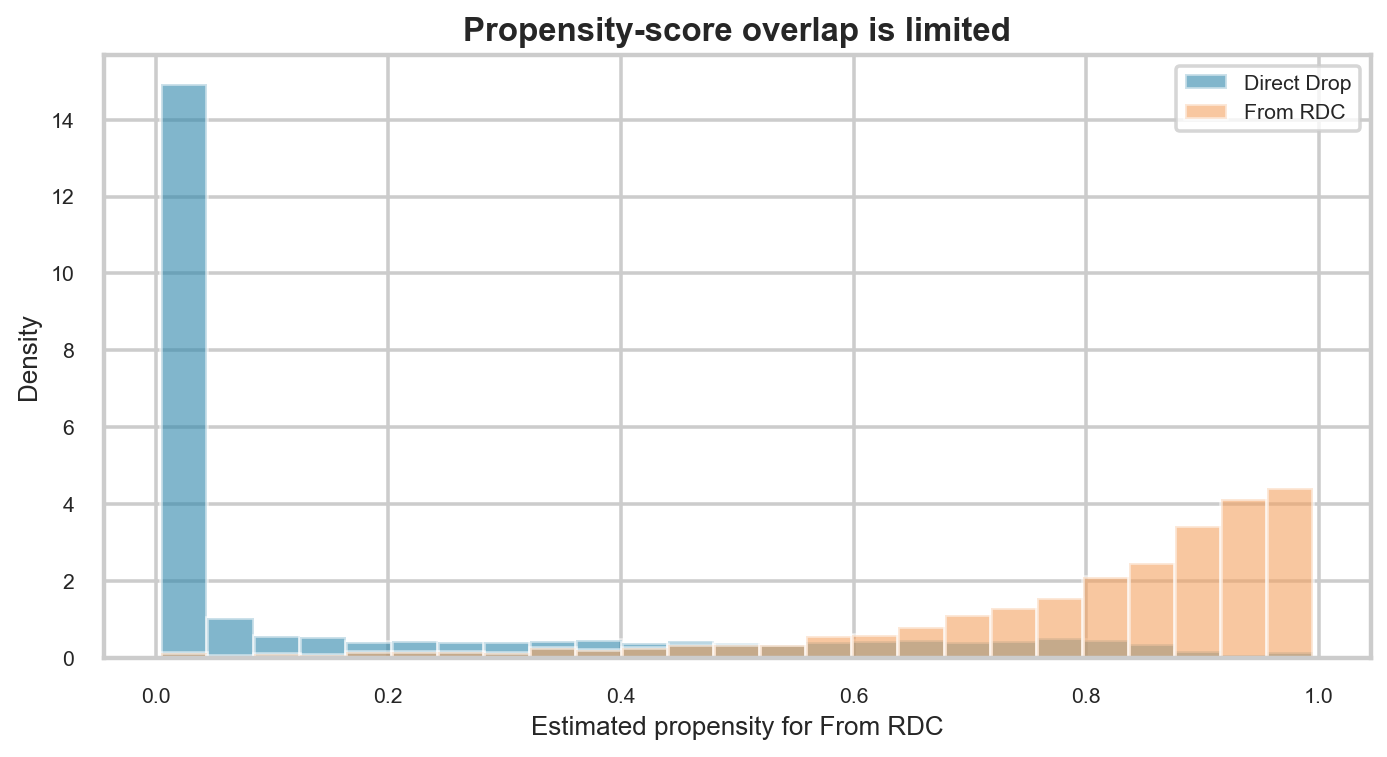

In [26]:
display(Image(filename=str(ROOT / 'reports/figures/causal_overlap.png'), width=850))

## 28. Business-impact scenario

Every monetary input is a configurable, unobserved assumption. Results are expected-value scenarios, not realized savings.

In [27]:
pd.read_csv(ROOT / 'reports/tables/business_impact_sensitivity.csv')

,capacity,intervention_success_rate_assumption,missed_delay_exposure_usd_assumption,review_cost_usd,expected_avoided_exposure_usd,expected_net_value_usd,break_even_success_rate
0,0.0500,0.1000,1000,"3,700.0000",700.0000,"-3,000.0000",0.5286
1,0.0500,0.1000,2500,"3,700.0000","1,750.0000","-1,950.0000",0.2114
2,0.0500,0.1000,5000,"3,700.0000","3,500.0000",-200.0000,0.1057
3,0.0500,0.2500,1000,"3,700.0000","1,750.0000","-1,950.0000",0.5286
4,0.0500,0.2500,2500,"3,700.0000","4,375.0000",675.0000,0.2114
5,0.0500,0.2500,5000,"3,700.0000","8,750.0000","5,050.0000",0.1057
6,0.0500,0.5000,1000,"3,700.0000","3,500.0000",-200.0000,0.5286
7,0.0500,0.5000,2500,"3,700.0000","8,750.0000","5,050.0000",0.2114
8,0.0500,0.5000,5000,"3,700.0000","17,500.0000","13,800.0000",0.1057
9,0.1000,0.1000,1000,"7,400.0000","2,600.0000","-4,800.0000",0.2846


## 29. Deployment

The serialized bundle contains preprocessing, classifier, and calibrator. `scripts/score.py`
validates a shipment-level CSV and emits calibrated probability, rank, and review flag. The
dashboard reads only generated local artifacts and requires no external service.

## 30. Monitoring

The monitoring design covers schema, nulls, invalid dates, unseen categories, numeric and
category drift, score drift, queue size, and delayed-label performance. Thresholds,
ownership assumptions, rollback, and retraining criteria are documented in
`docs/DEPLOYMENT_AND_MONITORING.md`.

In [28]:
drift = json.loads((ROOT / "reports/metrics/monitoring_drift_example.json").read_text(encoding="utf-8"))
pd.json_normalize(drift).T

,0
prediction_psi_train_to_test,0.2975
train_high_risk_rate_at_test_score_cutoff,0.2572
test_review_queue_rate,0.2001
numeric_psi_train_to_test.total_quantity,0.0288
numeric_psi_train_to_test.total_value_usd,0.0224
numeric_psi_train_to_test.weight_kg,0.1139
numeric_psi_train_to_test.freight_cost_usd,0.0953
category_frequency_distance_train_to_test.supplier,0.2258
category_frequency_distance_train_to_test.country,0.2224
category_frequency_distance_train_to_test.shipment_mode,0.1770


## 31. Limitations

The data is historical, ends in 2015, and describes one public-health supply-chain program.
Schedule-entry timestamps, on-hand inventory, intervention outcomes, urgency, contracts, and
many decision drivers are absent. Calibration has drifted in the final period. Segment
results are descriptive and may be unstable at low volume.

## 32. Final recommendation

Use the isotonic-calibrated logistic system as a transparent batch prioritization baseline at
the exact top-20% review capacity, with human review and drift monitoring. Do not deploy the
lead-time model or interpret observational fulfillment differences causally. Validate on
current local data before any real operational use.